In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
titanic = pd.read_csv('../data/train.csv')

In [58]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2)
for train_indices, test_indices in split.split(titanic, titanic[["Survived", "Pclass", "Sex"]]):
    strat_train_set = titanic.loc[train_indices]
    strat_test_set = titanic.loc[test_indices]

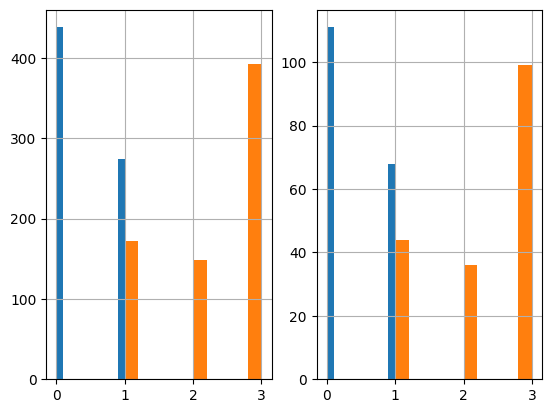

In [59]:
plt.subplot(1,2,1)
strat_train_set['Survived'].hist()
strat_train_set['Pclass'].hist()

plt.subplot(1,2,2)
strat_test_set['Survived'].hist()
strat_test_set['Pclass'].hist()
plt.show()

In [60]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 8 to 661
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    object 
 4   Sex          712 non-null    object 
 5   Age          576 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    object 
 9   Fare         712 non-null    float64
 10  Cabin        159 non-null    object 
 11  Embarked     710 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.3+ KB


In [61]:
from sklearn.pipeline import Pipeline
from structure import AgeImputer, FeatureEncoder, FeatureDropper

pipelines = Pipeline([
    ("ageimputer", AgeImputer()),
    ("featureencoder", FeatureEncoder()),
    ("featuredropper", FeatureDropper()),
])

In [62]:
strat_train_set = pipelines.fit_transform(strat_train_set)

In [63]:
strat_train_set

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Female,Male
8,9,1,3,27.0,0,2,11.1333,0.0,0.0,1.0,1.0,0.0
498,499,0,1,25.0,1,2,151.5500,0.0,0.0,1.0,1.0,0.0
436,437,0,3,21.0,2,2,34.3750,0.0,0.0,1.0,1.0,0.0
218,219,1,1,32.0,0,0,76.2917,1.0,0.0,0.0,1.0,0.0
216,217,1,3,27.0,0,0,7.9250,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
39,40,1,3,14.0,1,0,11.2417,1.0,0.0,0.0,1.0,0.0
392,393,0,3,28.0,2,0,7.9250,0.0,0.0,1.0,0.0,1.0
670,671,1,2,40.0,1,1,39.0000,0.0,0.0,1.0,1.0,0.0
345,346,1,2,24.0,0,0,13.0000,0.0,0.0,1.0,1.0,0.0


In [64]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 8 to 661
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Age          712 non-null    float64
 4   SibSp        712 non-null    int64  
 5   Parch        712 non-null    int64  
 6   Fare         712 non-null    float64
 7   C            712 non-null    float64
 8   S            712 non-null    float64
 9   Q            712 non-null    float64
 10  Female       712 non-null    float64
 11  Male         712 non-null    float64
dtypes: float64(7), int64(5)
memory usage: 72.3 KB


In [65]:
from sklearn.preprocessing import StandardScaler

X = strat_train_set.drop(['Survived','PassengerId'], axis=1)
y = strat_train_set['Survived']

scaler = StandardScaler()
X_data = scaler.fit_transform(X)
y_data = y.to_numpy()

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

clf = RandomForestClassifier()

params = [
    {
        "n_estimators": [10, 100, 200, 500],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 3, 4]
    }
]

grid_search = GridSearchCV(clf, param_grid=params, cv=3, scoring="accuracy", return_train_score=True)
grid_search.fit(X_data, y_data)

,estimator,RandomForestClassifier()
,param_grid,"[{'max_depth': [None, 5, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [10, 100, ...]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [67]:
final_clf = grid_search.best_estimator_
final_clf

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
strat_test_set = pipelines.fit_transform(strat_test_set)
strat_test_set

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Female,Male
566,567,0,3,19.000000,0,0,7.8958,0.0,0.0,1.0,0.0,1.0
736,737,0,3,48.000000,1,3,34.3750,0.0,0.0,1.0,1.0,0.0
580,581,1,2,25.000000,1,1,30.0000,0.0,0.0,1.0,1.0,0.0
471,472,0,3,38.000000,0,0,8.6625,0.0,0.0,1.0,0.0,1.0
549,550,1,2,8.000000,1,1,36.7500,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
481,482,0,2,28.996377,0,0,0.0000,0.0,0.0,1.0,0.0,1.0
261,262,1,3,3.000000,4,2,31.3875,0.0,0.0,1.0,0.0,1.0
342,343,0,2,28.000000,0,0,13.0000,0.0,0.0,1.0,0.0,1.0
219,220,0,2,30.000000,0,0,10.5000,0.0,0.0,1.0,0.0,1.0


In [69]:
Xt = strat_test_set.drop(['Survived','PassengerId'], axis=1)
yt = strat_test_set['Survived']

Xt_data = scaler.transform(Xt)
yt_data = yt.to_numpy()

In [70]:
final_clf.score(Xt_data, yt_data)

0.8379888268156425

In [71]:
titanic_test = pd.read_csv('../data/test.csv')

In [72]:
titanic_test_set = pipelines.fit_transform(titanic_test)
Xtt = titanic_test_set.drop(['PassengerId'], axis=1)

Xtt_data = scaler.transform(Xtt)

In [73]:
ytt_pred = final_clf.predict(Xtt_data)
ytt_pred

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [79]:
results = titanic_test[['PassengerId']]
results['Survived'] = ytt_pred
results.to_csv('../data/titanic_prediction.csv', header=True, index=False)

/tmp/ipykernel_15213/1388375609.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Survived'] = ytt_pred
